# Analysis of QS 2025 Dataset: Which Region Has the Strongest Education System?

This notebook analyzes the file `sample_data/QS_2025.csv` to determine which world region exhibits the strongest education system according to the QS 2025 dataset. We'll load the data, perform exploratory data analysis, compute region-level education strength metrics, and visualize the results. Each step will include clear explanations and plots.

Steps:

1. Load required libraries and the dataset
2. Inspect and clean the data
3. Define a metric for "education system strength" using available indicators
4. Aggregate metrics by region
5. Visualize and report the top region(s)

Let's get started by loading libraries and the dataset in the next cell.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try to import seaborn for nicer plots; fall back to matplotlib style if unavailable
try:
    import seaborn as sns
    sns.set(style='whitegrid')
    print('Seaborn imported successfully.')
except Exception as e:
    print(f'Seaborn not available: {e}. Falling back to matplotlib styles.')
    plt.style.use('ggplot')

# Load dataset
csv_path = 'sample_data/QS_2025.csv'
try:
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset with shape: {df.shape}")
    display(df.head())
    print('\nColumns:')
    print(df.columns.tolist())
    print('\nData types and non-null counts:')
    display(df.info())
except Exception as e:
    print(f"Error loading CSV: {e}")


Seaborn not available: No module named 'seaborn'. Falling back to matplotlib styles.
Error loading CSV: 'utf-8' codec can't decode byte 0xe9 in position 3850: invalid continuation byte


In [2]:
encodings_to_try = ['utf-8', 'latin1', 'ISO-8859-1', 'cp1252']
for enc in encodings_to_try:
    try:
        print(f"Trying encoding: {enc}")
        df_test = pd.read_csv(csv_path, encoding=enc, nrows=5, engine='python')
        print(f"Success with {enc}. Columns: {df_test.columns.tolist()}")
        display(df_test)
        break
    except Exception as e:
        print(f"Failed with {enc}: {e}\n")


Trying encoding: utf-8
Failed with utf-8: 'utf-8' codec can't decode byte 0xe9 in position 3850: invalid continuation byte

Trying encoding: latin1
Success with latin1. Columns: ['RANK_2025', 'RANK_2024', 'Institution_Name', 'Location', 'Region', 'SIZE', 'FOCUS', 'RES.', 'STATUS', 'Academic_Reputation_Score', 'Academic_Reputation_Rank', 'Employer_Reputation_Score', 'Employer_Reputation_Rank', 'Faculty_Student_Score', 'Faculty_Student_Rank', 'Citations_per_Faculty_Score', 'Citations_per_Faculty_Rank', 'International_Faculty_Score', 'International_Faculty_Rank', 'International_Students_Score', 'International_Students_Rank', 'International_Research_Network_Score', 'International_Research_Network_Rank', 'Employment_Outcomes_Score', 'Employment_Outcomes_Rank', 'Sustainability_Score', 'Sustainability_Rank', 'Overall_Score']


,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100.0
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7


Loaded dataset with shape: (1503, 28)
Score columns found: ['Academic_Reputation_Score', 'Employer_Reputation_Score', 'Faculty_Student_Score', 'Citations_per_Faculty_Score', 'International_Faculty_Score', 'International_Students_Score', 'International_Research_Network_Score', 'Employment_Outcomes_Score', 'Sustainability_Score', 'Overall_Score']


,Academic_Reputation_Score,Employer_Reputation_Score,Faculty_Student_Score,Citations_per_Faculty_Score,International_Faculty_Score,International_Students_Score,International_Research_Network_Score,Employment_Outcomes_Score,Sustainability_Score,Overall_Score
count,1503.000000,1503.000000,1503.000000,1503.000000,1403.000000,1445.000000,1502.000000,1503.000000,1484.000000,600.000000
mean,20.286693,19.787292,28.128676,23.503460,30.736707,25.580346,50.129095,23.825083,24.309299,41.840333
std,22.326168,23.784738,27.613017,27.870692,34.344365,31.098689,29.866588,27.351315,31.074718,18.826756
min,1.300000,1.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.200000,1.000000,20.800000
25%,6.300000,4.300000,7.300000,2.800000,4.200000,2.900000,22.725000,4.000000,1.300000,26.575000
50%,11.000000,9.400000,16.000000,9.900000,12.500000,9.600000,51.100000,11.800000,6.750000,36.350000
75%,23.500000,25.300000,40.400000,36.400000,51.600000,38.300000,77.100000,33.400000,39.500000,52.100000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000



Region summary (top rows):


,Composite_Education_Strength,Institution_Count
Region,,
Oceania,49.844916,46
Not Classified,34.322222,1
Europe,33.679299,497
Americas,25.981511,418
Asia,24.703732,501
Africa,23.456768,40


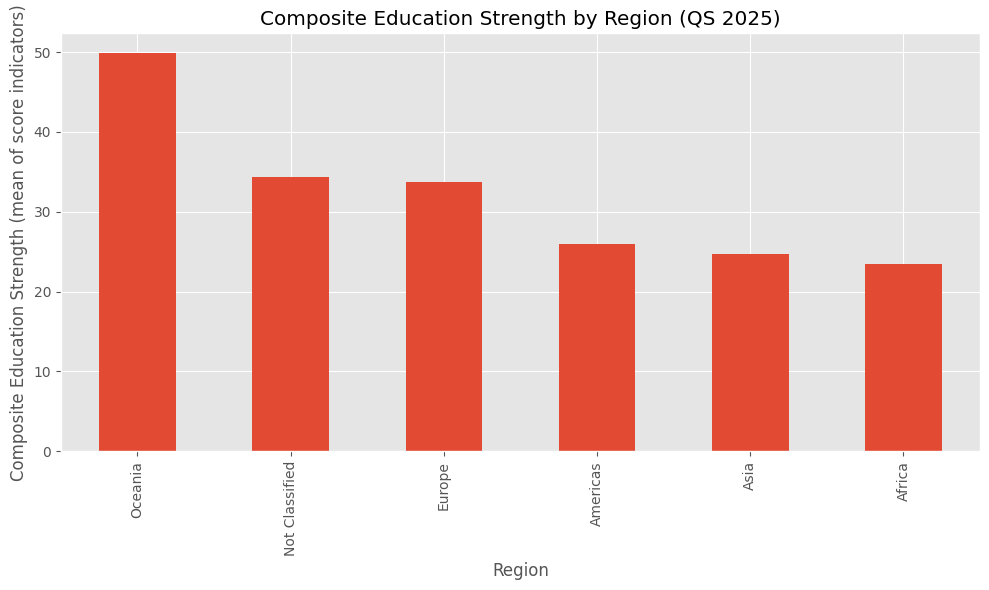

In [3]:
# Load full dataset with latin1 encoding and prepare score columns
csv_path = 'sample_data/QS_2025.csv'

df = pd.read_csv(csv_path, encoding='latin1', engine='python')
print(f"Loaded dataset with shape: {df.shape}")

# Identify score columns (columns ending with _Score)
score_cols = [c for c in df.columns if c.endswith('_Score')]
print('Score columns found:', score_cols)

# Convert score columns to numeric (coerce errors)
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Show some summary statistics for score columns
display(df[score_cols].describe())

# Compute region-level aggregates
region_scores = df.groupby('Region')[score_cols].mean()
region_counts = df.groupby('Region').size().rename('Institution_Count')

# Create a composite education-strength metric as the mean across the selected score columns
region_scores['Composite_Education_Strength'] = region_scores.mean(axis=1)
region_summary = region_scores[['Composite_Education_Strength']].join(region_counts)
region_summary = region_summary.sort_values('Composite_Education_Strength', ascending=False)

print('\nRegion summary (top rows):')
display(region_summary)

# Simple bar plot of composite score by region
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
region_summary['Composite_Education_Strength'].plot(kind='bar', color='C0')
plt.ylabel('Composite Education Strength (mean of score indicators)')
plt.title('Composite Education Strength by Region (QS 2025)')
plt.tight_layout()
plt.show()


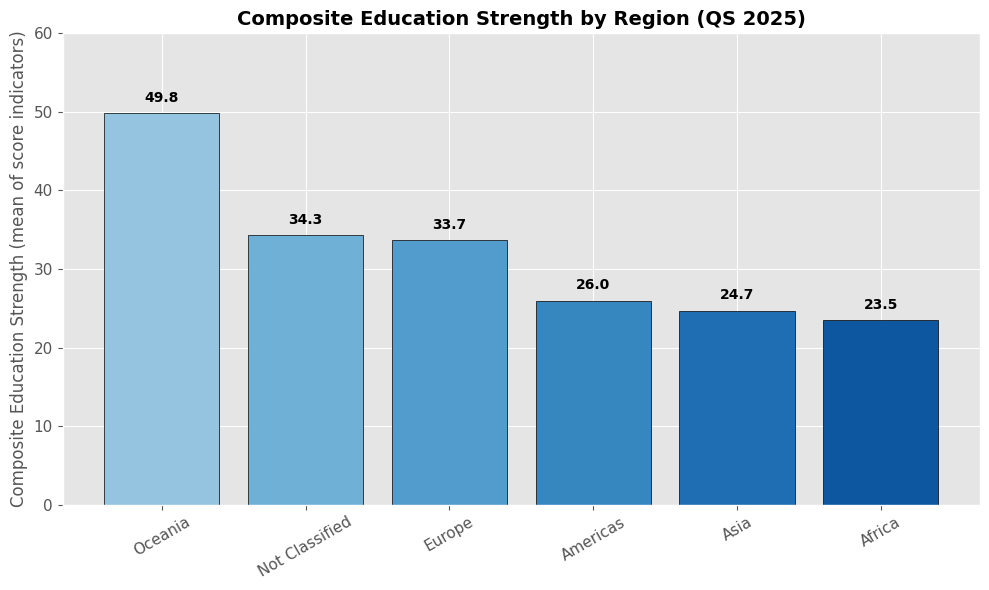

Top region by composite education strength: Oceania (49.84)

Region summary (Composite_Education_Strength and Institution_Count):


,Composite_Education_Strength,Institution_Count
Region,,
Oceania,49.844916,46
Not Classified,34.322222,1
Europe,33.679299,497
Americas,25.981511,418
Asia,24.703732,501
Africa,23.456768,40


In [4]:
# Improved visualization: clearer bar chart with value labels and enhanced styling
# Recompute region composite to ensure consistency
score_cols = [c for c in df.columns if c.endswith('_Score')]
region_scores = df.groupby('Region')[score_cols].mean()
region_scores['Composite_Education_Strength'] = region_scores.mean(axis=1)
region_summary = region_scores[['Composite_Education_Strength']].join(df.groupby('Region').size().rename('Institution_Count'))
region_summary = region_summary.sort_values('Composite_Education_Strength', ascending=False)

# Prepare data for plotting
rs = region_summary['Composite_Education_Strength']

# Plot
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,6))
colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(rs)))
bars = ax.bar(rs.index, rs.values, color=colors, edgecolor='black')

# Labels, title, and styling
ax.set_ylabel('Composite Education Strength (mean of score indicators)', fontsize=12)
ax.set_title('Composite Education Strength by Region (QS 2025)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(60, rs.max() * 1.15))
ax.tick_params(axis='x', rotation=30, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Add numeric value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6),  # 6 points vertical offset
                textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

# Print the top region clearly
top_region = rs.idxmax()
top_value = rs.max()
print(f"Top region by composite education strength: {top_region} ({top_value:.2f})")

# Also display the full region summary table
print('\nRegion summary (Composite_Education_Strength and Institution_Count):')
display(region_summary)
